# Random forest

<center>
  <img src="https://miro.medium.com/max/1170/1*58f1CZ8M4il0OZYg2oRN4w.png"/><br>
  image from: <a href="https://medium.com/@ar.ingenious/applying-random-forest-classification-machine-learning-algorithm-from-scratch-with-real-24ff198a1c57">APPLYING RANDOM FOREST (CLASSIFICATION) — MACHINE LEARNING ALGORITHM FROM SCRATCH WITH REAL DATASETS</a>
</center>

- by [<img src="https://scikit-learn.org/stable/_static/scikit-learn-logo-small.png" height="32"/> scikit-learn (RandomForestClassifier)](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier)

## สร้าง DataFrame

- ใช้ dataset จากไฟล์ `winequality.csv`
  1. **Fixed Acidity (ความเป็นกรดคงที่):** ปริมาณกรดในไวน์ที่ไม่ระเหยได้ง่าย มีความสำคัญในการให้รสชาติเปรี้ยว

  2. **Volatile Acidity (ความเป็นกรดระเหย):** ปริมาณกรดที่ระเหยได้ง่ายเช่น กรดแอซิติก ถ้ามีปริมาณมากเกินไปจะทำให้ไวน์มีกลิ่นเหมือนน้ำส้มสายชู

  3. **Citric Acid (กรดซิตริก):** กรดที่พบในผลไม้ ให้รสชาติเปรี้ยวสดชื่นและช่วยเพิ่มความสดของไวน์

  4. **Residual Sugar (น้ำตาลที่เหลืออยู่):** ปริมาณน้ำตาลที่ยังเหลืออยู่หลังจากการหมัก ไวน์ที่มีน้ำตาลเหลือมากจะมีรสหวาน

  5. **Chlorides (คลอไรด์):** ปริมาณเกลือในไวน์ ถ้ามีปริมาณมากเกินไปจะทำให้ไวน์มีรสเค็ม

  6. **Free Sulfur Dioxide (ซัลเฟอร์ไดออกไซด์อิสระ):** ปริมาณซัลเฟอร์ไดออกไซด์ในไวน์ที่ไม่ได้ทำปฏิกิริยากับสารอื่นๆ ช่วยป้องกันไวน์จากการออกซิเดชันและการเสียหายจากเชื้อรา

  7. **Total Sulfur Dioxide (ซัลเฟอร์ไดออกไซด์ทั้งหมด):** ปริมาณรวมของซัลเฟอร์ไดออกไซด์ทั้งที่อิสระและที่ทำปฏิกิริยากับสารอื่นๆในไวน์

  8. **Density (ความหนาแน่น):** ความหนาแน่นของไวน์ ซึ่งมีความสัมพันธ์กับปริมาณน้ำตาลและแอลกอฮอล์ในไวน์

  9. **pH (ค่าความเป็นกรด-ด่าง):** ค่าที่แสดงความเป็นกรดหรือเบสของไวน์ ไวน์ทั่วไปจะมีค่า pH อยู่ระหว่าง 3 ถึง 4

  10. **Sulphates (ซัลเฟต):** สารประกอบที่ช่วยเพิ่มกลิ่นหอมของไวน์และป้องกันการเกิดออกซิเดชัน

  11. **Alcohol (แอลกอฮอล์):** ปริมาณแอลกอฮอล์ในไวน์ มีผลต่อรสชาติและความรู้สึกเมา

  12. **Quality (คุณภาพ):** คุณภาพของไวน์ 0 - Bad Wine, 1 - Good Wine

- อัพโหลดขึ้น Google drive หรือเรียกใช้จาก [https://raw.githubusercontent.com/AjKaew/DGA306/main/winequality.csv](https://raw.githubusercontent.com/AjKaew/DGA306/main/winequality.csv)
- เรียกใช้ `pandas`
- อ่านไฟล์ `winequality.csv`

```python
wine_df = pd.read_csv('data/WineQT.csv')
```

In [1]:
import pandas as pd
wine_df = pd.read_csv('data/WineQT.csv')
wine_df
wine_df = wine_df.drop(columns=['Id'], errors='ignore')


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,1
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,0
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,1
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,1
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,0


- ตรวจสอบจำนวน class

```python
wine_df.quality.value_counts()
```

In [2]:
wine_df.quality.value_counts()

quality
1    855
0    744
Name: count, dtype: int64

- ในที่นี้ต้องการทำนาย `quality`

```python
X = wine_df.drop(['quality'], axis=1)
y = wine_df.quality
```

In [3]:
X = wine_df.drop(['quality'], axis=1)
y = wine_df.quality

- แบ่งข้อมูลออกเป็นชุดการเรียนรู้ และชุดทดสอบ โดยใช้ `train_test_split`
- แบ่งข้อมูลสำหรับเรียน 80% สำหรับทดสอบ 20%

```python
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=?, test_size=?)
```

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

## สร้าง RandomForest Classifier Model

- เรียกใช้งาน `RandomForestClassifier` library

```python
from sklearn.ensemble import RandomForestClassifier
```

In [5]:
from sklearn.ensemble import RandomForestClassifier

- สร้าง model

```python
wine_cf = RandomForestClassifier(n_estimators=?, random_state=?)
```

### Bagging

In [6]:
wine_cf_bagging = RandomForestClassifier(n_estimators=3, random_state=42, max_features=None, max_samples=.75, max_depth=3)

- เรียนรู้จากชุดข้อมูล

In [7]:
wine_cf_bagging.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, max_features=None, max_samples=0.75,
                       n_estimators=3, random_state=42)

- ในกรณีนี้ class อยู่ในรูปแบบของตัวเลข
  - 0 - Bad Wine
  - 1 - Good Wine

```python
wine_cf.classes_
```

In [8]:
wine_cf_bagging.classes_

array([0, 1])

- จึงสร้างเป็น tuple ของ class name ตาม label ที่มี

```python
wine_classes = ('Bad Wine', 'Good Wine')
```

In [9]:
wine_classes = ('Bad Wine', 'Good Wine')

- ดู tree ย่อยที่อยู่ในชุด estimators

```python
wine_cf.estimators_[0]
```

In [10]:
wine_cf_bagging.estimators_[0]

DecisionTreeClassifier(max_depth=3, random_state=1608637542)

- แสดง tree แบบข้อความ

```python
print(export_text(tree, feature_names=wine_cf.feature_names_in_))
```

In [11]:
from sklearn.tree import export_text

for i, tree in enumerate(wine_cf_bagging.estimators_):
  print(f"Tree {i}:")
  print(export_text(tree, feature_names=wine_cf_bagging.feature_names_in_))

Tree 0:
|--- alcohol <= 9.85
|   |--- sulphates <= 0.58
|   |   |--- pH <= 3.54
|   |   |   |--- class: 0.0
|   |   |--- pH >  3.54
|   |   |   |--- class: 1.0
|   |--- sulphates >  0.58
|   |   |--- fixed acidity <= 10.00
|   |   |   |--- class: 0.0
|   |   |--- fixed acidity >  10.00
|   |   |   |--- class: 1.0
|--- alcohol >  9.85
|   |--- sulphates <= 0.58
|   |   |--- alcohol <= 11.45
|   |   |   |--- class: 0.0
|   |   |--- alcohol >  11.45
|   |   |   |--- class: 1.0
|   |--- sulphates >  0.58
|   |   |--- alcohol <= 11.25
|   |   |   |--- class: 1.0
|   |   |--- alcohol >  11.25
|   |   |   |--- class: 1.0

Tree 1:
|--- sulphates <= 0.62
|   |--- alcohol <= 10.35
|   |   |--- sulphates <= 0.51
|   |   |   |--- class: 0.0
|   |   |--- sulphates >  0.51
|   |   |   |--- class: 0.0
|   |--- alcohol >  10.35
|   |   |--- free sulfur dioxide <= 10.50
|   |   |   |--- class: 0.0
|   |   |--- free sulfur dioxide >  10.50
|   |   |   |--- class: 1.0
|--- sulphates >  0.62
|   |--- tota

### Random subspaces

In [12]:
wine_cf_subspaces = RandomForestClassifier(n_estimators=3, random_state=42, max_features=.8, max_depth=3)

In [13]:
wine_cf_subspaces.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, max_features=0.8, n_estimators=3,
                       random_state=42)

In [14]:
for i, tree in enumerate(wine_cf_subspaces.estimators_):
  print(f"Tree {i}:")
  print(export_text(tree, feature_names=wine_cf_subspaces.feature_names_in_))

Tree 0:
|--- alcohol <= 9.95
|   |--- sulphates <= 0.56
|   |   |--- volatile acidity <= 0.23
|   |   |   |--- class: 1.0
|   |   |--- volatile acidity >  0.23
|   |   |   |--- class: 0.0
|   |--- sulphates >  0.56
|   |   |--- total sulfur dioxide <= 81.50
|   |   |   |--- class: 0.0
|   |   |--- total sulfur dioxide >  81.50
|   |   |   |--- class: 0.0
|--- alcohol >  9.95
|   |--- sulphates <= 0.58
|   |   |--- alcohol <= 11.45
|   |   |   |--- class: 0.0
|   |   |--- alcohol >  11.45
|   |   |   |--- class: 1.0
|   |--- sulphates >  0.58
|   |   |--- alcohol <= 11.25
|   |   |   |--- class: 1.0
|   |   |--- alcohol >  11.25
|   |   |   |--- class: 1.0

Tree 1:
|--- sulphates <= 0.62
|   |--- alcohol <= 10.35
|   |   |--- sulphates <= 0.51
|   |   |   |--- class: 0.0
|   |   |--- sulphates >  0.51
|   |   |   |--- class: 0.0
|   |--- alcohol >  10.35
|   |   |--- free sulfur dioxide <= 10.50
|   |   |   |--- class: 0.0
|   |   |--- free sulfur dioxide >  10.50
|   |   |   |--- class

### Random patches

In [15]:
wine_cf_patches = RandomForestClassifier(n_estimators=3, random_state=42, max_features=.8, max_samples=.75, max_depth=3)

In [16]:
wine_cf_patches.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, max_features=0.8, max_samples=0.75,
                       n_estimators=3, random_state=42)

In [17]:
for i, tree in enumerate(wine_cf_patches.estimators_):
  print(f"Tree {i}:")
  print(export_text(tree, feature_names=wine_cf_patches.feature_names_in_))

Tree 0:
|--- alcohol <= 9.85
|   |--- sulphates <= 0.58
|   |   |--- pH <= 3.54
|   |   |   |--- class: 0.0
|   |   |--- pH >  3.54
|   |   |   |--- class: 1.0
|   |--- sulphates >  0.58
|   |   |--- total sulfur dioxide <= 82.50
|   |   |   |--- class: 1.0
|   |   |--- total sulfur dioxide >  82.50
|   |   |   |--- class: 0.0
|--- alcohol >  9.85
|   |--- sulphates <= 0.58
|   |   |--- alcohol <= 11.45
|   |   |   |--- class: 0.0
|   |   |--- alcohol >  11.45
|   |   |   |--- class: 1.0
|   |--- sulphates >  0.58
|   |   |--- alcohol <= 11.25
|   |   |   |--- class: 1.0
|   |   |--- alcohol >  11.25
|   |   |   |--- class: 1.0

Tree 1:
|--- sulphates <= 0.62
|   |--- alcohol <= 10.35
|   |   |--- sulphates <= 0.51
|   |   |   |--- class: 0.0
|   |   |--- sulphates >  0.51
|   |   |   |--- class: 0.0
|   |--- alcohol >  10.35
|   |   |--- free sulfur dioxide <= 10.50
|   |   |   |--- class: 0.0
|   |   |--- free sulfur dioxide >  10.50
|   |   |   |--- class: 1.0
|--- sulphates >  0.62

- แสดง tree แบบกราฟ

```python
plt.figure(figsize=(100, 100))
plot_tree(tree, feature_names=wine_cf.feature_names_in_,
          class_names=wine_classes, filled=True, rounded=True)
plt.show()
```

In [18]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(100, 100))
plot_tree(wine_cf_patches.estimators_[0],
          feature_names=wine_cf_patches.feature_names_in_,
          class_names=wine_classes, filled=True, rounded=True)
plt.show()

## ใช้ model ที่ผ่านการเรียนรู้แล้วในการทำนาย

```python
wine_cf = RandomForestClassifier(n_estimators=10, random_state=42, max_features=None, max_samples=.75)
wine_cf.fit(X_train, y_train)
predictions = wine_cf.predict(X_test)
```

In [19]:
wine_cf = RandomForestClassifier(n_estimators=10, random_state=42, max_features=None, max_samples=.75)
wine_cf.fit(X_train, y_train)
predictions = wine_cf.predict(X_test)
predictions

array([0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,

In [20]:
pd.DataFrame({'Actual': y_test, 'Predicted': predictions})

,Actual,Predicted
803,1,0
124,0,0
350,1,1
682,0,0
1326,1,1
...,...,...
1259,1,1
1295,0,0
1155,0,0
963,1,1


- ดูผลลัพธ์ที่ได้จาก Tree แต่ละต้น

In [21]:
sample = X_test.iloc[[112]]
for i, tree in enumerate(wine_cf.estimators_):
  pred = tree.predict(sample.values) # Pass the values without feature names
  print(f"Tree {i}: class {int(pred[0])} {wine_classes[int(pred[0])]}")

Tree 0: class 1 Good Wine
Tree 1: class 1 Good Wine
Tree 2: class 1 Good Wine
Tree 3: class 0 Bad Wine
Tree 4: class 1 Good Wine
Tree 5: class 1 Good Wine
Tree 6: class 1 Good Wine
Tree 7: class 0 Bad Wine
Tree 8: class 1 Good Wine
Tree 9: class 0 Bad Wine


* Evaluation

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.71      0.79      0.75       141
           1       0.82      0.74      0.78       179

    accuracy                           0.77       320
   macro avg       0.76      0.77      0.76       320
weighted avg       0.77      0.77      0.77       320



## Feature Importance

In [23]:
feature_importances = pd.Series(wine_cf.feature_importances_, index=wine_cf.feature_names_in_, name='Score')
feature_importances.sort_values(ascending=False)

alcohol                 0.229813
sulphates               0.138382
volatile acidity        0.097574
total sulfur dioxide    0.094873
chlorides               0.080758
pH                      0.066615
density                 0.066568
free sulfur dioxide     0.060165
citric acid             0.059433
fixed acidity           0.058235
residual sugar          0.047584
Name: Score, dtype: float64

## Predict new data

In [24]:
wine_new = pd.DataFrame([
  [5.9, 0.645, 0.12, 2.0, 0.075, 32.0, 35.0, 1, 3.57, 0.71, 11.2],
  [2.9, 1.5, 1.12, 3.0, 1.075, 32.0, 30.0, 1, 3.57, 2.71, 9.2]
], columns=X_test.columns)
wine_new

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,5.9,0.645,0.12,2.0,0.075,32.0,35.0,1,3.57,0.71,11.2
1,2.9,1.500,1.12,3.0,1.075,32.0,30.0,1,3.57,2.71,9.2


In [25]:
wine_cf.predict(wine_new)

array([1, 0])

## Finding the Optimal estimators

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [100, 200, 300]}
clf = RandomForestClassifier(random_state=42, max_features=.8, max_samples=.75)
grid = GridSearchCV(clf, param_grid, cv=5)
grid.fit(X_train, y_train)
grid.best_params_

{'n_estimators': 300}

## Finding the Optimal estimators using OOB error curve

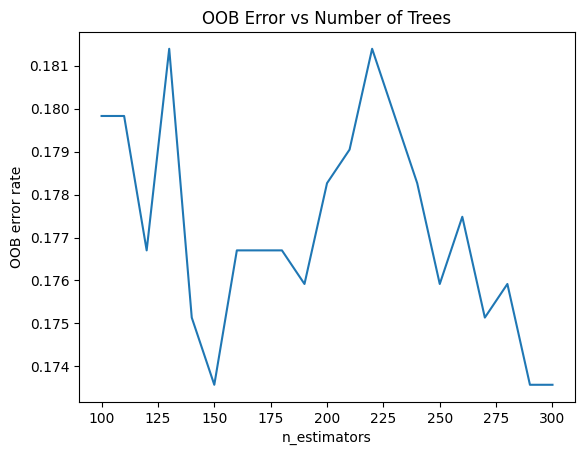

In [27]:
oob_errors = []
for n in range(100, 301, 10):
  model = RandomForestClassifier(
    n_estimators=n, oob_score=True, random_state=42,
    max_features=.8, max_samples=.75)
  model.fit(X_train, y_train)
  oob_errors.append(1 - model.oob_score_)

plt.plot(range(100, 301, 10), oob_errors)
plt.xlabel('n_estimators')
plt.ylabel('OOB error rate')
plt.title('OOB Error vs Number of Trees')
plt.show()